## 0- What We Do!!

## 1- Merge DATA

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df1 = pd.DataFrame({
    'Customer_ID':[1,2,3,4],
    'name': ['Ahmed','Ali','Omar','Aya'],
    'Courses': ['AI','ML','AI','UI']
})

In [3]:
df2 = pd.DataFrame({
    'Customer_ID':[2,3,4,5],
    'purchase': ['Laptop','Tab','Phone','Monitor'],
    'Courses': ['ML','AI','UI','Web']
})

In [4]:
df1

,Customer_ID,name,Courses
0,1,Ahmed,AI
1,2,Ali,ML
2,3,Omar,AI
3,4,Aya,UI


In [5]:
df2

,Customer_ID,purchase,Courses
0,2,Laptop,ML
1,3,Tab,AI
2,4,Phone,UI
3,5,Monitor,Web


In [6]:
inner_join = pd.merge(df1,df2, how='inner',on = ['Customer_ID','Courses'])

In [7]:
inner_join

,Customer_ID,name,Courses,purchase
0,2,Ali,ML,Laptop
1,3,Omar,AI,Tab
2,4,Aya,UI,Phone


In [8]:
Right_join = pd.merge(df1,df2, how='right',on = ['Customer_ID','Courses'])

In [9]:
Right_join

,Customer_ID,name,Courses,purchase
0,2,Ali,ML,Laptop
1,3,Omar,AI,Tab
2,4,Aya,UI,Phone
3,5,NaN,Web,Monitor


In [10]:
Left_join = pd.merge(df1,df2, how='left',on = ['Customer_ID','Courses'])

In [11]:
Left_join

,Customer_ID,name,Courses,purchase
0,1,Ahmed,AI,NaN
1,2,Ali,ML,Laptop
2,3,Omar,AI,Tab
3,4,Aya,UI,Phone


In [12]:
full_join = pd.merge(df1,df2, how='outer',on = ['Customer_ID','Courses'])

In [13]:
full_join

,Customer_ID,name,Courses,purchase
0,1,Ahmed,AI,NaN
1,2,Ali,ML,Laptop
2,3,Omar,AI,Tab
3,4,Aya,UI,Phone
4,5,NaN,Web,Monitor


## 2- Handle Missing Values

In [14]:
data = pd.DataFrame({
    'Age': [25,30,None,45,50,None,65],
    'Blood_press': [120,130,110,None,140,145,None],
    'choles': [200,None,190,210,None,180,200]
})

In [15]:
data

,Age,Blood_press,choles
0,25.0,120.0,200.0
1,30.0,130.0,NaN
2,NaN,110.0,190.0
3,45.0,NaN,210.0
4,50.0,140.0,NaN
5,NaN,145.0,180.0
6,65.0,NaN,200.0


In [16]:
data.isnull().sum()

Age            2
Blood_press    2
choles         2
dtype: int64

### 2.1 Remove Null Values

In [17]:
data_copy = data

In [18]:
data_copy

,Age,Blood_press,choles
0,25.0,120.0,200.0
1,30.0,130.0,NaN
2,NaN,110.0,190.0
3,45.0,NaN,210.0
4,50.0,140.0,NaN
5,NaN,145.0,180.0
6,65.0,NaN,200.0


In [19]:
data_copy = data_copy.dropna()

In [20]:
data_copy

,Age,Blood_press,choles
0,25.0,120.0,200.0


In [21]:
data_copy2 = data

In [22]:
data_copy2

,Age,Blood_press,choles
0,25.0,120.0,200.0
1,30.0,130.0,NaN
2,NaN,110.0,190.0
3,45.0,NaN,210.0
4,50.0,140.0,NaN
5,NaN,145.0,180.0
6,65.0,NaN,200.0


In [23]:
df_drp = data_copy2.dropna(subset = ['Blood_press'])

In [24]:
df_drp 

,Age,Blood_press,choles
0,25.0,120.0,200.0
1,30.0,130.0,NaN
2,NaN,110.0,190.0
4,50.0,140.0,NaN
5,NaN,145.0,180.0


### 2.2 Imputation for Null Values

In [25]:
import warnings
warnings.filterwarnings('ignore')

In [26]:
data

,Age,Blood_press,choles
0,25.0,120.0,200.0
1,30.0,130.0,NaN
2,NaN,110.0,190.0
3,45.0,NaN,210.0
4,50.0,140.0,NaN
5,NaN,145.0,180.0
6,65.0,NaN,200.0


In [27]:
data.Age.value_counts()

Age
25.0    1
30.0    1
45.0    1
50.0    1
65.0    1
Name: count, dtype: int64

In [28]:
data['Age'].fillna(data['Age'].mean(),inplace = True)

In [29]:
data

,Age,Blood_press,choles
0,25.0,120.0,200.0
1,30.0,130.0,NaN
2,43.0,110.0,190.0
3,45.0,NaN,210.0
4,50.0,140.0,NaN
5,43.0,145.0,180.0
6,65.0,NaN,200.0


In [30]:
data['Blood_press'].fillna(data['Blood_press'].mean(),inplace = True)
data['choles'].fillna(180,inplace = True)

In [31]:
data

,Age,Blood_press,choles
0,25.0,120.0,200.0
1,30.0,130.0,180.0
2,43.0,110.0,190.0
3,45.0,129.0,210.0
4,50.0,140.0,180.0
5,43.0,145.0,180.0
6,65.0,129.0,200.0


In [32]:
data.isnull().sum()

Age            0
Blood_press    0
choles         0
dtype: int64

## 3- Detect & Handle Outliers

### 3.1 ZScore

In [33]:
df = pd.DataFrame({
    'values' : [10,12,12,13,14,14,15,16,10000,200]
})

In [34]:
df

,values
0,10
1,12
2,12
3,13
4,14
5,14
6,15
7,16
8,10000
9,200


In [35]:
# z = (x -M)/std

df['zscore']= (df['values'] -df['values'].mean())/df['values'].std()

In [36]:
df

,values,zscore
0,10,-0.323787
1,12,-0.323152
2,12,-0.323152
3,13,-0.322835
4,14,-0.322518
5,14,-0.322518
6,15,-0.322201
7,16,-0.321883
8,10000,2.845556
9,200,-0.263509


In [37]:
threshold = 2.5
outliers = df[np.abs(df['zscore'])>threshold]

In [38]:
outliers

,values,zscore
8,10000,2.845556


### 3.2 IOR

In [39]:
df = pd.DataFrame({
    'values' : [10,12,12,13,14,14,15,16,10000,200]
})

In [40]:
Q1 = df['values'].quantile(0.25)
Q3 = df['values'].quantile(0.75)

In [41]:
IQR = Q3-Q1
IQR

3.5

In [42]:
outliers = df[(df['values']<Q1 - 1.5*IQR)|(df['values'] >Q3+1.5*IQR)]

In [43]:
outliers

,values
8,10000
9,200


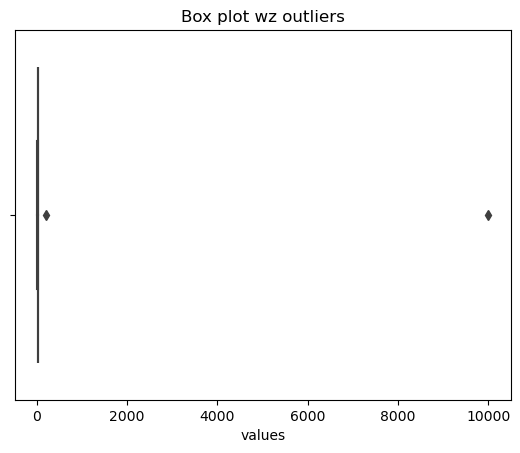

In [44]:
sns.boxplot(x = df['values'])
plt.title('Box plot wz outliers')
plt.show()

In [45]:
df_clean = df[(df['values']>=Q1 - 1.5*IQR)&(df['values'] <=Q3+1.5*IQR)]

In [46]:
df_clean

,values
0,10
1,12
2,12
3,13
4,14
5,14
6,15
7,16


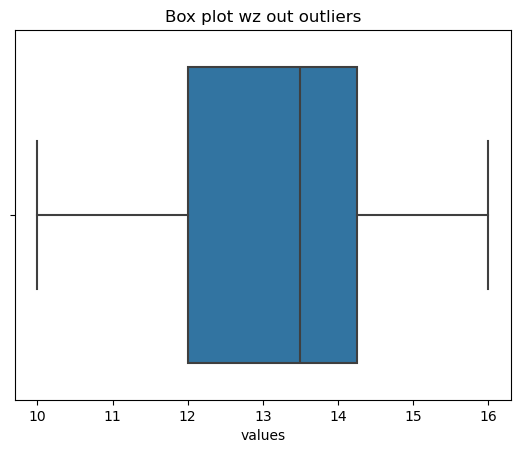

In [47]:
sns.boxplot(x = df_clean['values'])
plt.title('Box plot wz out outliers')
plt.show()

##  4- Encoding

In [48]:
Categorical

    - Nominal --> ['Male','Female']
    - Ordinal --> ['D','C','B-','B+','A']

IndentationError: unexpected indent (2544652013.py, line 3)

### 4.1 Ordinal Numbers Encoding

#### 4.1.1 Manual

In [ ]:
data = pd.DataFrame({
    'Tepm': ['Hot','Cold','very Hot','Cold','Warm','Hot','Warm']
})

In [ ]:
data

In [ ]:
data.Tepm.unique()

'Cold'       -- 1
'Warm'       -- 2
'Hot'        -- 3
'very Hot'   -- 4

In [ ]:
temp_values = {'Cold':1,'Warm':2,'Hot':3,'very Hot':4}
temp_values

In [ ]:
data

In [ ]:
data['Tepm_encod'] = data['Tepm'].map(temp_values)

In [ ]:
data

In [ ]:
data.drop(['Tepm'],axis = 1,inplace = True)

In [ ]:
data

#### 4.1.2 py Tools

In [ ]:
!pip install category_encoders

In [ ]:
import category_encoders as ce

In [ ]:
data = pd.DataFrame({
    'Tepm': ['Hot','Cold','very Hot','Cold','Warm','Hot','Warm']
})

In [ ]:
data

In [ ]:
ordinal_encoder = ce.OrdinalEncoder(cols = 'Tepm',
                                   return_df = True,
                                   mapping = [{'col':'Tepm',
                                               'mapping':{
                                                   'Cold':1,
                                                   'Warm':2,
                                                   'Hot':3,
                                                   'very Hot':4
                                               }}])

In [ ]:
data.Tepm=ordinal_encoder.fit_transform(data)

In [ ]:
data

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

In [ ]:
data = pd.DataFrame({
    'Tepm': ['Hot','Cold','very Hot','Cold','Warm','Hot','Warm']
})

In [ ]:
#call 
encoder = OrdinalEncoder()

In [ ]:
data['Tep_enco']=encoder.fit_transform(data)

In [ ]:
data

In [ ]:
!pip install category-encoders

In [50]:
import category_encoders as ce

In [51]:
data = pd.DataFrame({
    'Gender':['m','f','m','m','f'],
    'Class':['A','B','C','D','A'],
    'City':['Cairo','Giza','Cairo','Giza','Giza']
})

In [52]:
data

,Gender,Class,City
0,m,A,Cairo
1,f,B,Giza
2,m,C,Cairo
3,m,D,Giza
4,f,A,Giza


In [ ]:
data['Class'].unique()

In [53]:
binary_enc = ce.BinaryEncoder(cols = ['Class'])

In [54]:
new_df = binary_enc.fit_transform(data)

In [55]:
new_df

,Gender,Class_0,Class_1,Class_2,City
0,m,0,0,1,Cairo
1,f,0,1,0,Giza
2,m,0,1,1,Cairo
3,m,1,0,0,Giza
4,f,0,0,1,Giza


In [57]:
data = pd.get_dummies(data,columns=['Gender'],drop_first = True)

In [58]:
data

,Class,City,Gender_m
0,A,Cairo,True
1,B,Giza,False
2,C,Cairo,True
3,D,Giza,True
4,A,Giza,False
